# 07 Separator (IA-SEP-001)

**Requirement:** `IA-SEP-001`

Patents: US12308414B2, EP4602674A1. Equations are paraphrased; see claims/paragraphs cited below.

## Governing equations

$$R_\mathrm{ionic} = \frac{L\,\tau}{\sigma A \varepsilon s^{1.5}}$$

Separator blocks dissolved $\mathrm{O_2}$ and bubbles from iron without a large
ionic penalty, remaining hydrophilic/macroporous (US FIG. 4A; EP Claim 2, [0048]).
Wrapped stacked-core pores $1\,\mathrm{\mu m}$ to $1\,\mathrm{cm}$ (US FIG. 36A).


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

here = Path.cwd()
for cand in (here, here.parent):
    if (cand / "src" / "ironair").is_dir() and (cand / "plant_sim").is_dir():
        sys.path.insert(0, str(cand))
        sys.path.insert(0, str(cand / "src"))
        break

from plant_sim.bootstrap import setup_path

setup_path()
from plant_sim.params import CAPACITY_FE_OH2_MAH_G, CAPACITY_MAGNETITE_MAH_G, default_params

In [2]:
from IPython import get_ipython

_ipy = get_ipython()
if _ipy is not None:
    _ipy.run_line_magic("matplotlib", "inline")

sns.set(
    rc={
        "axes.labelsize": 12,
        "axes.titlesize": 18,
        "figure.figsize": (11, 8.5),
        "figure.dpi": 300,
        "figure.facecolor": "w",
        "figure.edgecolor": "k",
    }
)
P = default_params()
print("KOH default", P.c_KOH_mol_m3 / 1000, "M; T_ep", P.T_ep_sim_K, "K")
print("Faraday 960/320 checks", round(CAPACITY_FE_OH2_MAH_G, 2), round(CAPACITY_MAGNETITE_MAH_G, 2))

KOH default 6.0 M; T_ep 303.15 K
Faraday 960/320 checks 959.85 319.95


## Simulation setup

Integrate the model once. Plot sections below each document what is shown, why it matters for patent/requirement verification, and the equations that govern that view.


In [3]:
from plant_sim.components.separator import Separator
from plant_sim.components.base import integrate_component

sep = Separator(P)
t, y = integrate_component(
    lambda t, y: sep.rhs(
        t,
        y,
        {"T_ely_K": P.T_ep_sim_K, "c_KOH_mol_m3": 6000, "I_cell_A": 5.0, "s_wet": 0.95, "c_O2_ely_mol_m3": 0.02},
        {},
    ),
    sep.y0(),
    (0, 800),
    n_eval=100,
)
R = [
    sep.outputs(float(ti), y[:, i], {"c_KOH_mol_m3": 6000, "I_cell_A": 5.0}, {})["R_ionic_ohm"]
    for i, ti in enumerate(t)
]

## Separator ionic resistance and oxygen block

### What this plot illustrates

Ionic resistance vs saturation and the separator as an $\mathrm{O_2}$ diffusion barrier between air cathode and iron anode.

### Governing equations

$$R_\mathrm{ionic} = \frac{L\,\tau}{\sigma A \varepsilon s^{1.5}}$$


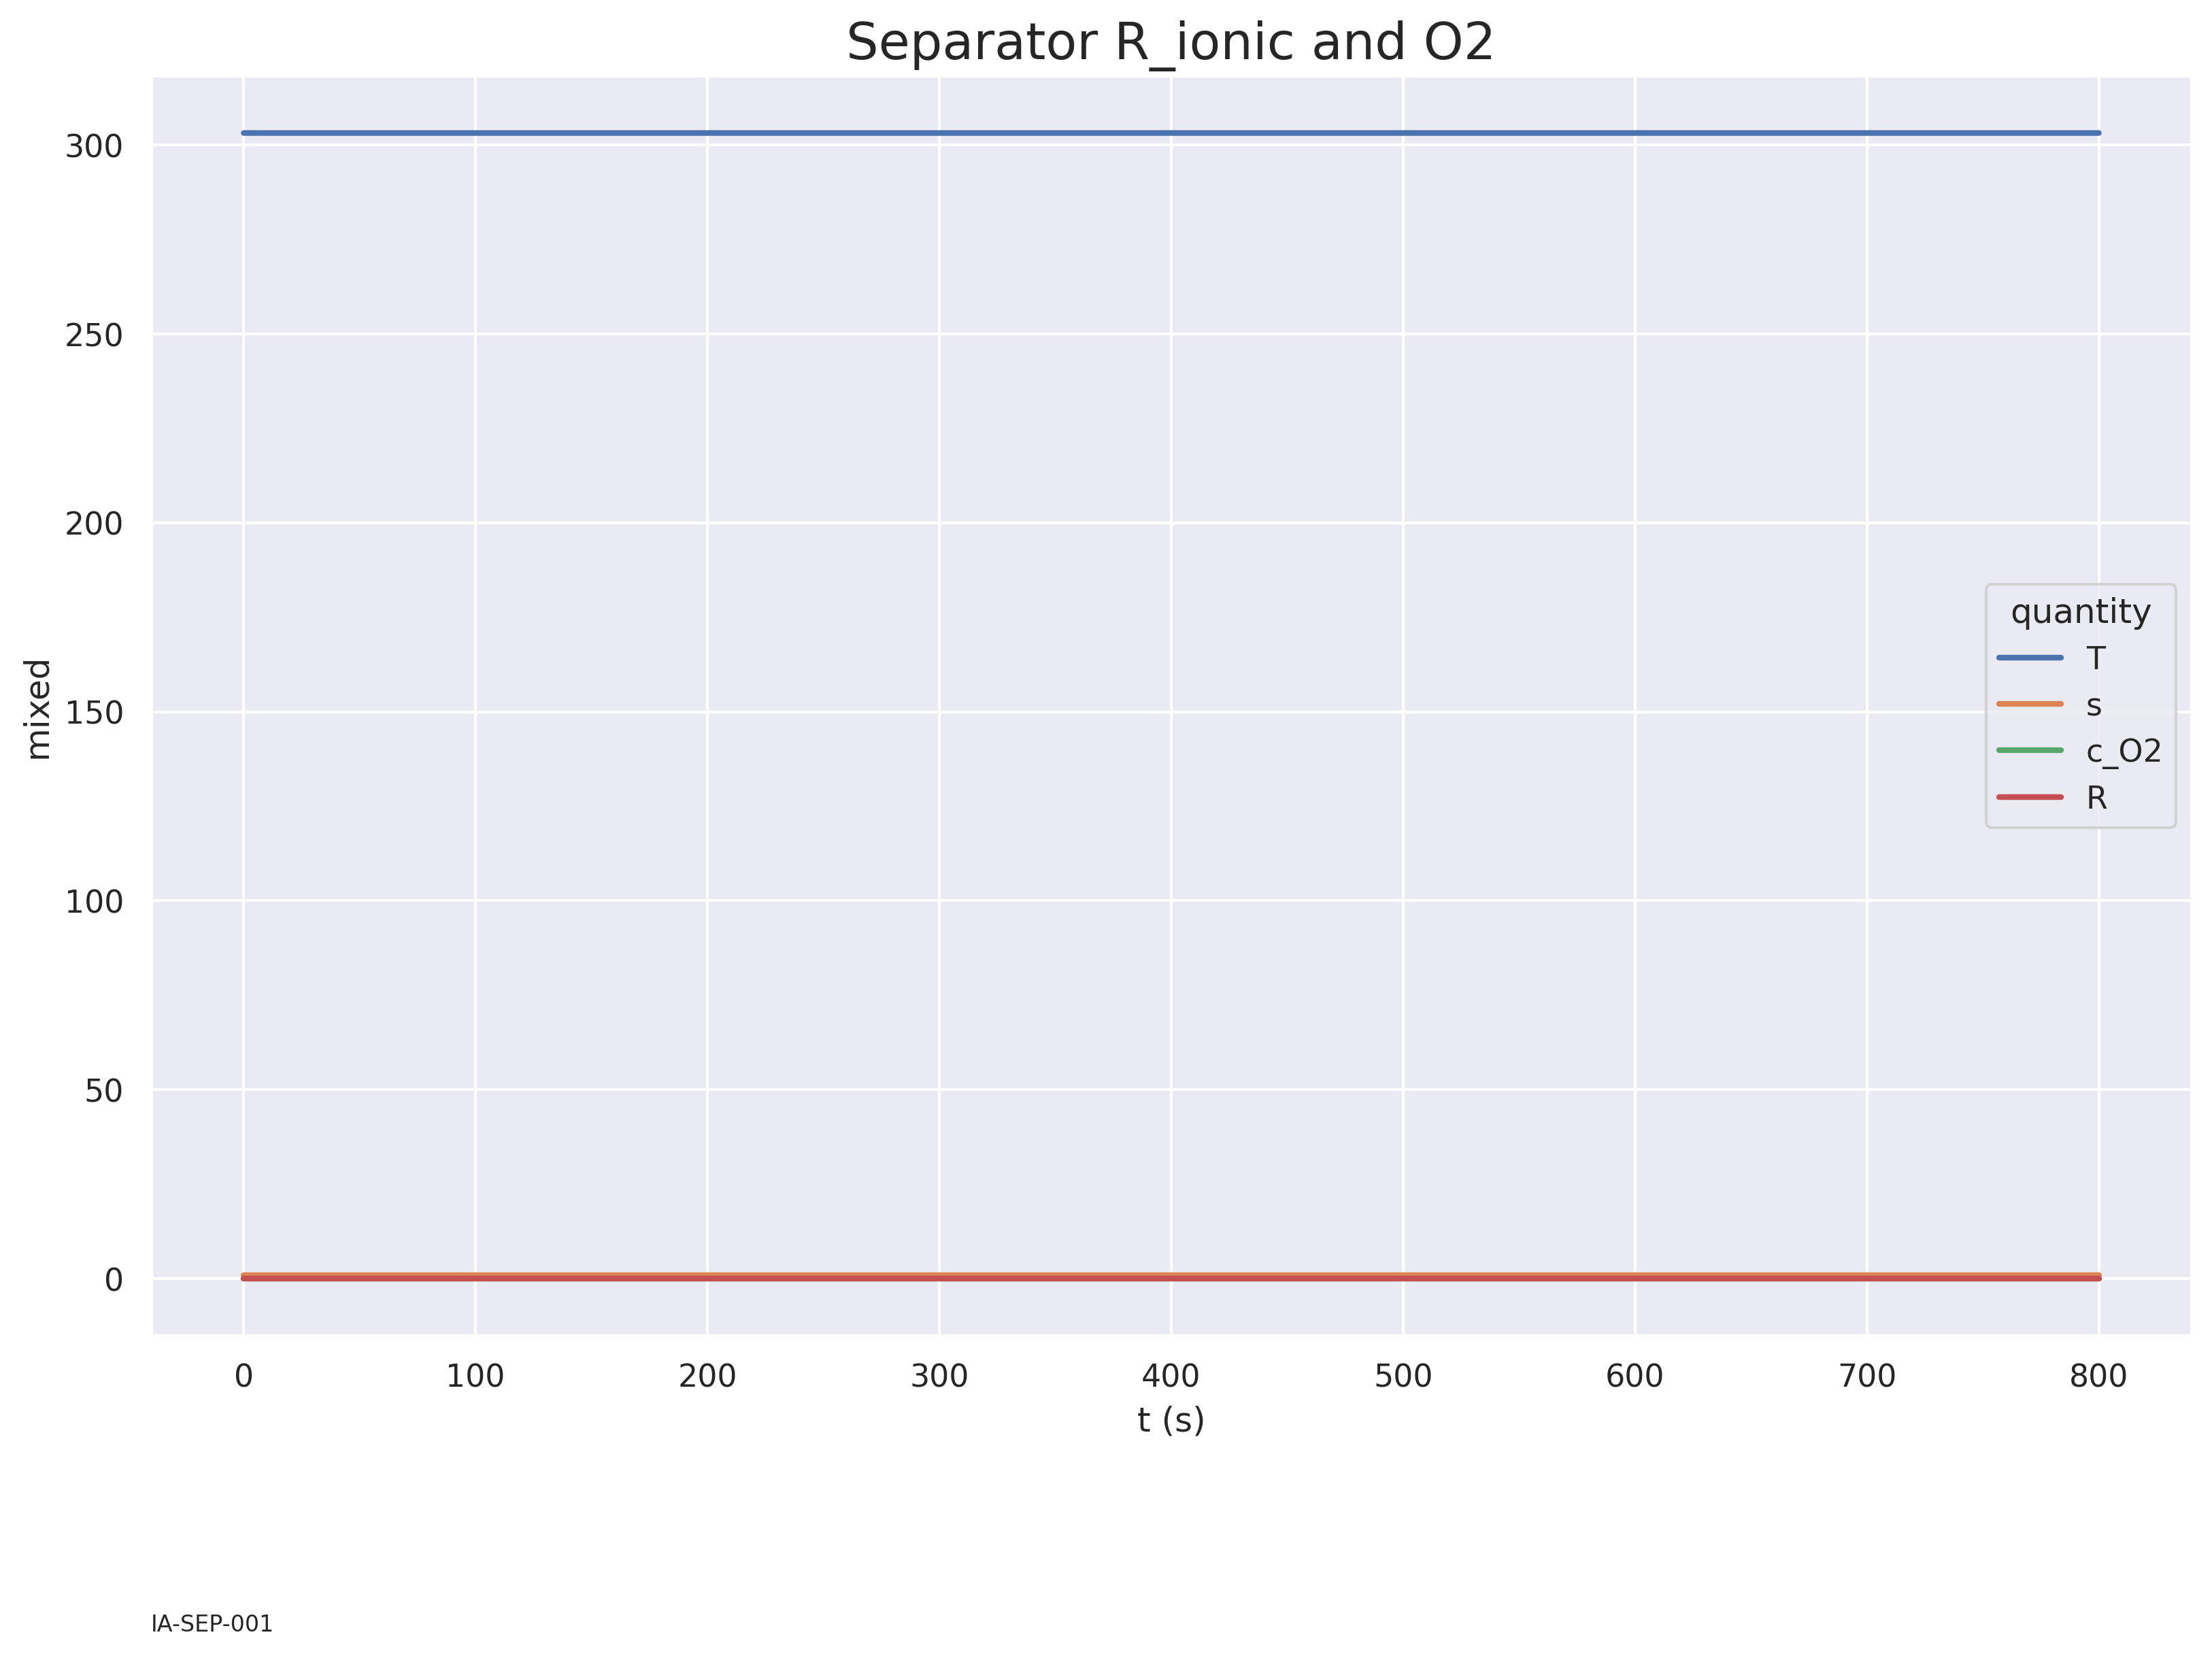

In [4]:
plot_frame = pd.DataFrame(
    {
        "t": (t),
        "T": (y[0]),
        "s": (y[1]),
        "c_O2": (y[2]),
        "R": (R),
    }
)
plot_long = plot_frame.melt(id_vars="t", var_name="quantity", value_name="value")
fig, ax = plt.subplots()
sns.lineplot(data=plot_long, x="t", y="value", hue="quantity", ax=ax, linewidth=2.0)
ax.set_xlabel("t (s)")
ax.set_ylabel("mixed")
ax.set_title("Separator R_ionic and O2")
ax.text(0.0, -0.22, "IA-SEP-001", transform=ax.transAxes, fontsize=8, va="top")
fig.tight_layout()
fig.subplots_adjust(bottom=0.22)

## Verification against patents / SSS002

In [5]:
print("R_ionic is algebraic in conductivity, thickness, area, saturation.")

R_ionic is algebraic in conductivity, thickness, area, saturation.
